In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!nvidia-smi

Sat May 16 13:43:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.5 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import pandas as pd
from collections import Counter
import shutil
import random
from PIL import Image
import matplotlib.pyplot as plt

from ultralytics import YOLO

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

ALPHADENT_DATASET = BASE_DIR / "data_prepared" / "alphadent_yolo_seg_2class"
DATA_YAML = ALPHADENT_DATASET / "data.yaml"

RUNS_DIR = BASE_DIR / "runs" / "alphadent"
RESULTS_DIR = BASE_DIR / "results" / "alphadent_training"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "alphadent"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("AlphaDent dataset:", ALPHADENT_DATASET)
print("data.yaml:", DATA_YAML)
print("data.yaml var mı?:", DATA_YAML.exists())
print("runs dir:", RUNS_DIR)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
AlphaDent dataset: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class
data.yaml: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/data.yaml
data.yaml var mı?: True
runs dir: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent


In [5]:
print(DATA_YAML.read_text())

path: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class
train: images/train
val: images/val

names:
  0: dis_asinmasi
  1: dis_curugu


In [6]:
def count_split(split):
    img_dir = ALPHADENT_DATASET / "images" / split
    label_dir = ALPHADENT_DATASET / "labels" / split

    img_count = len(list(img_dir.glob("*")))
    label_count = len(list(label_dir.glob("*.txt")))

    return img_count, label_count

rows = []

for split in ["train", "val"]:
    img_count, label_count = count_split(split)
    rows.append({
        "split": split,
        "images": img_count,
        "labels": label_count
    })

df_split_counts = pd.DataFrame(rows)
df_split_counts

,split,images,labels
0,train,1208,1208
1,val,82,82


In [8]:
class_names = {
    0: "dis_asinmasi",
    1: "dis_curugu"
}

counter = Counter()

label_dirs = [
    ALPHADENT_DATASET / "labels" / "train",
    ALPHADENT_DATASET / "labels" / "val"
]

label_paths = []

for label_dir in label_dirs:
    label_paths.extend(list(label_dir.glob("*.txt")))

print("Toplam label dosyası:", len(label_paths))

for label_path in label_paths:
    try:
        lines = label_path.read_text(errors="ignore").strip().splitlines()
    except Exception as e:
        print("Okunamadı:", label_path, e)
        continue

    for line in lines:
        if line.strip() == "":
            continue

        parts = line.split()
        cls_id = int(float(parts[0]))
        counter[cls_id] += 1

df_class_counts = pd.DataFrame([
    {
        "class_id": cls_id,
        "class_name": class_names.get(cls_id, f"class_{cls_id}"),
        "count": count
    }
    for cls_id, count in sorted(counter.items())
])

df_class_counts

Toplam label dosyası: 1290


,class_id,class_name,count
0,0,dis_asinmasi,6347
1,1,dis_curugu,3563


In [9]:
def count_classes_by_split(dataset_dir):
    rows = []

    for split in ["train", "val"]:
        label_dir = dataset_dir / "labels" / split
        split_counter = Counter()

        label_paths = list(label_dir.glob("*.txt"))
        print(split, "label dosyası:", len(label_paths))

        for label_path in label_paths:
            try:
                lines = label_path.read_text(errors="ignore").strip().splitlines()
            except Exception as e:
                print("Okunamadı:", label_path, e)
                continue

            for line in lines:
                if line.strip() == "":
                    continue

                parts = line.split()
                cls_id = int(float(parts[0]))
                split_counter[cls_id] += 1

        for cls_id, count in sorted(split_counter.items()):
            rows.append({
                "split": split,
                "class_id": cls_id,
                "class_name": class_names.get(cls_id, f"class_{cls_id}"),
                "count": count
            })

    return pd.DataFrame(rows)

df_split_class_counts = count_classes_by_split(ALPHADENT_DATASET)
df_split_class_counts

train label dosyası: 1208
val label dosyası: 82


,split,class_id,class_name,count
0,train,0,dis_asinmasi,5939
1,train,1,dis_curugu,3305
2,val,0,dis_asinmasi,408
3,val,1,dis_curugu,258


In [10]:
experiments = [
    {
        "model_name": "YOLOv8n-seg",
        "weights": "yolov8n-seg.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolov8n_seg_640_30ep"
    },
    {
        "model_name": "YOLOv8s-seg",
        "weights": "yolov8s-seg.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolov8s_seg_640_30ep"
    },
    {
        "model_name": "YOLOv8m-seg",
        "weights": "yolov8m-seg.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 4,
        "run_name": "yolov8m_seg_640_30ep"
    },
    {
        "model_name": "YOLO11s-seg",
        "weights": "yolo11s-seg.pt",
        "imgsz": 640,
        "epochs": 30,
        "batch": 8,
        "run_name": "yolo11s_seg_640_30ep"
    }
]

pd.DataFrame(experiments)

,model_name,weights,imgsz,epochs,batch,run_name
0,YOLOv8n-seg,yolov8n-seg.pt,640,30,8,yolov8n_seg_640_30ep
1,YOLOv8s-seg,yolov8s-seg.pt,640,30,8,yolov8s_seg_640_30ep
2,YOLOv8m-seg,yolov8m-seg.pt,640,30,4,yolov8m_seg_640_30ep
3,YOLO11s-seg,yolo11s-seg.pt,640,30,8,yolo11s_seg_640_30ep


In [11]:
def train_and_evaluate_seg(exp):
    print("\n" + "=" * 120)
    print("DENEY BAŞLIYOR:", exp["run_name"])
    print("Model:", exp["model_name"])
    print("Weights:", exp["weights"])
    print("imgsz:", exp["imgsz"], "| epochs:", exp["epochs"], "| batch:", exp["batch"])
    print("=" * 120)

    try:
        model = YOLO(exp["weights"])

        model.train(
            data=str(DATA_YAML),
            epochs=exp["epochs"],
            imgsz=exp["imgsz"],
            batch=exp["batch"],
            device=0,
            project=str(RUNS_DIR),
            name=exp["run_name"],
            exist_ok=True,
            patience=10,
            workers=2,
            cache=False
        )

        exp_dir = RUNS_DIR / exp["run_name"]
        best_model_path = exp_dir / "weights" / "best.pt"

        print("\nBest model path:", best_model_path)
        print("Best var mı?:", best_model_path.exists())

        if not best_model_path.exists():
            raise FileNotFoundError(f"best.pt bulunamadı: {best_model_path}")

        best_model = YOLO(str(best_model_path))

        val_name = exp["run_name"] + "_val"

        val_metrics = best_model.val(
            data=str(DATA_YAML),
            split="val",
            imgsz=exp["imgsz"],
            batch=exp["batch"],
            device=0,
            project=str(RUNS_DIR),
            name=val_name,
            exist_ok=True
        )

        summary = {
            "status": "ok",
            "model": exp["model_name"],
            "weights": exp["weights"],
            "run_name": exp["run_name"],
            "imgsz": exp["imgsz"],
            "epochs": exp["epochs"],
            "batch": exp["batch"],

            # Box metrikleri
            "box_precision": float(val_metrics.box.mp),
            "box_recall": float(val_metrics.box.mr),
            "box_mAP50": float(val_metrics.box.map50),
            "box_mAP50-95": float(val_metrics.box.map),

            # Mask metrikleri
            "mask_precision": float(val_metrics.seg.mp),
            "mask_recall": float(val_metrics.seg.mr),
            "mask_mAP50": float(val_metrics.seg.map50),
            "mask_mAP50-95": float(val_metrics.seg.map),

            "best_model_path": str(best_model_path),
            "error": ""
        }

        print("\nVALIDATION SONUCU:")
        display(pd.DataFrame([summary]))

        return summary

    except Exception as e:
        print("\nHATA OLUŞTU:", exp["run_name"])
        print(str(e))

        summary = {
            "status": "failed",
            "model": exp["model_name"],
            "weights": exp["weights"],
            "run_name": exp["run_name"],
            "imgsz": exp["imgsz"],
            "epochs": exp["epochs"],
            "batch": exp["batch"],
            "box_precision": None,
            "box_recall": None,
            "box_mAP50": None,
            "box_mAP50-95": None,
            "mask_precision": None,
            "mask_recall": None,
            "mask_mAP50": None,
            "mask_mAP50-95": None,
            "best_model_path": "",
            "error": str(e)
        }

        return summary

In [12]:
all_seg_results = []

for exp in experiments:
    result = train_and_evaluate_seg(exp)
    all_seg_results.append(result)

    # Her deneyden sonra ara kayıt
    df_temp = pd.DataFrame(all_seg_results)
    temp_csv = RESULTS_DIR / "alphadent_seg_model_comparison_running.csv"
    df_temp.to_csv(temp_csv, index=False)
    print("Ara sonuç kaydedildi:", temp_csv)

df_seg_results = pd.DataFrame(all_seg_results)
df_seg_results


DENEY BAŞLIYOR: yolov8n_seg_640_30ep
Model: YOLOv8n-seg
Weights: yolov8n-seg.pt
imgsz: 640 | epochs: 30 | batch: 8
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0,

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_running.csv

DENEY BAŞLIYOR: yolov8s_seg_640_30ep
Model: YOLOv8s-seg
Weights: yolov8s-seg.pt
imgsz: 640 | epochs: 30 | batch: 8
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.43992,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_running.csv

DENEY BAŞLIYOR: yolov8m_seg_640_30ep
Model: YOLOv8m-seg
Weights: yolov8m-seg.pt
imgsz: 640 | epochs: 30 | batch: 4
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_running.csv

DENEY BAŞLIYOR: yolo11s_seg_640_30ep
Model: YOLO11s-seg
Weights: yolo11s-seg.pt
imgsz: 640 | epochs: 30 | batch: 8
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


Ara sonuç kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_running.csv


,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
1,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
2,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
3,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


In [13]:
df_seg_success = df_seg_results[df_seg_results["status"] == "ok"].copy()
df_seg_success

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
1,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
2,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
3,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


In [14]:
df_seg_success = df_seg_results[df_seg_results["status"] == "ok"].copy()
df_seg_success

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
1,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
2,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
3,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


In [16]:
df_seg_success = df_seg_results[df_seg_results["status"] == "ok"].copy()

df_seg_results_sorted = df_seg_success.sort_values(
    "mask_mAP50",
    ascending=False
).reset_index(drop=True)

df_seg_results_sorted

,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
1,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
2,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
3,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


In [17]:
compare_csv = RESULTS_DIR / "alphadent_seg_model_comparison_first_round_30ep.csv"

df_seg_results_sorted.to_csv(compare_csv, index=False)

print("Karşılaştırma kaydedildi:")
print(compare_csv)

Karşılaştırma kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_first_round_30ep.csv


In [18]:
best_row = df_seg_results_sorted.iloc[0]

best_model_name = best_row["model"]
best_run_name = best_row["run_name"]
best_model_path = Path(best_row["best_model_path"])

print("İlk tur en iyi AlphaDent segmentasyon modeli:")
print("Model:", best_model_name)
print("Run:", best_run_name)
print("Box mAP50:", best_row["box_mAP50"])
print("Box mAP50-95:", best_row["box_mAP50-95"])
print("Mask mAP50:", best_row["mask_mAP50"])
print("Mask mAP50-95:", best_row["mask_mAP50-95"])
print("Best path:", best_model_path)

İlk tur en iyi AlphaDent segmentasyon modeli:
Model: YOLOv8m-seg
Run: yolov8m_seg_640_30ep
Box mAP50: 0.6205839096229581
Box mAP50-95: 0.45979501771358383
Mask mAP50: 0.612123561256956
Mask mAP50-95: 0.41145727134622473
Best path: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent/yolov8m_seg_640_30ep/weights/best.pt


In [19]:
final_model_path = FINAL_MODELS_DIR / f"{best_run_name}_best.pt"

shutil.copy2(best_model_path, final_model_path)

print("Final model kopyalandı:")
print(final_model_path)

Final model kopyalandı:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/alphadent/yolov8m_seg_640_30ep_best.pt


In [20]:
best_model = YOLO(str(best_model_path))

split_summaries = []

for split in ["train", "val"]:
    print("\n" + "=" * 80)
    print("Değerlendirilen split:", split)
    print("=" * 80)

    metrics = best_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=int(best_row["imgsz"]),
        batch=int(best_row["batch"]),
        device=0,
        project=str(RUNS_DIR),
        name=f"{best_run_name}_{split}_check",
        exist_ok=True
    )

    split_summaries.append({
        "model": best_model_name,
        "run_name": best_run_name,
        "split": split,

        "box_precision": float(metrics.box.mp),
        "box_recall": float(metrics.box.mr),
        "box_mAP50": float(metrics.box.map50),
        "box_mAP50-95": float(metrics.box.map),

        "mask_precision": float(metrics.seg.mp),
        "mask_recall": float(metrics.seg.mr),
        "mask_mAP50": float(metrics.seg.map50),
        "mask_mAP50-95": float(metrics.seg.map)
    })

df_best_split_metrics = pd.DataFrame(split_summaries)
df_best_split_metrics


Değerlendirilen split: train
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,223,542 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 530.4±205.5 MB/s, size: 3082.9 KB)
val: Scanning /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/labels/train.cache... 1208 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1208/1208 361.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 302/302 8.6it/s 35.2s
                   all       1208       9244      0.657      0.672      0.701      0.522      0.654       0.67      0.695      0.465
          dis_asinmasi       1065       5939      0.735      0.867      0.874      0.804      0.735      0.867      0.874      0.728
            dis_curugu        846       3305      0.579      

,model,run_name,split,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95
0,YOLOv8m-seg,yolov8m_seg_640_30ep,train,0.657216,0.672300,0.700787,0.521759,0.654048,0.669665,0.695478,0.465363
1,YOLOv8m-seg,yolov8m_seg_640_30ep,val,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457


In [21]:
split_metrics_csv = RESULTS_DIR / f"{best_run_name}_train_val_metrics.csv"

df_best_split_metrics.to_csv(split_metrics_csv, index=False)

print("Kaydedildi:", split_metrics_csv)

Kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/yolov8m_seg_640_30ep_train_val_metrics.csv


In [22]:
pred_name = best_run_name + "_predictions_conf25"

pred_result = best_model.predict(
    source=str(ALPHADENT_DATASET / "images" / "val"),
    imgsz=int(best_row["imgsz"]),
    conf=0.25,
    device=0,
    project=str(RUNS_DIR),
    name=pred_name,
    exist_ok=True,
    save=True
)

PRED_DIR = RUNS_DIR / pred_name

print("Prediction klasörü:", PRED_DIR)
print("Var mı?:", PRED_DIR.exists())


image 1/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p001_F_51_001.jpg: 448x640 6 dis_asinmasis, 1 dis_curugu, 102.0ms
image 2/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p001_F_51_002.jpg: 448x640 5 dis_asinmasis, 11.3ms
image 3/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p001_F_51_003.jpg: 448x640 4 dis_asinmasis, 11.5ms
image 4/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p001_F_51_004.jpg: 448x640 4 dis_asinmasis, 11.0ms
image 5/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p015_M_53_001.jpg: 448x640 8 dis_asinmasis, 11.1ms
image 6/82 /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class/images/val/p015_M_53_002.jpg: 448x640 5 dis_asinmasis, 9 dis_curugus, 11.0ms
image 7/82 /content/drive/MyDrive/DIS_PROJESI_007/data_pr

In [23]:
pred_images = list(PRED_DIR.glob("*.jpg")) + list(PRED_DIR.glob("*.png"))

print("Tahmin görsel sayısı:", len(pred_images))

if len(pred_images) > 0:
    sample_preds = random.sample(pred_images, min(8, len(pred_images)))

    for img_path in sample_preds:
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()
else:
    print("Tahmin görseli bulunamadı.")

Output hidden; open in https://colab.research.google.com to view.

In [24]:
print("AlphaDent YOLO-seg ilk tur model karşılaştırması tamamlandı.")
print("=" * 100)

print("Karşılaştırma CSV:", compare_csv)
print("En iyi model:", best_model_name)
print("En iyi run:", best_run_name)
print("Final model:", final_model_path)

display(df_seg_results_sorted)
display(df_best_split_metrics)

AlphaDent YOLO-seg ilk tur model karşılaştırması tamamlandı.
Karşılaştırma CSV: /content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_first_round_30ep.csv
En iyi model: YOLOv8m-seg
En iyi run: yolov8m_seg_640_30ep
Final model: /content/drive/MyDrive/DIS_PROJESI_007/final_models/alphadent/yolov8m_seg_640_30ep_best.pt


,status,model,weights,run_name,imgsz,epochs,batch,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,best_model_path,error
0,ok,YOLOv8m-seg,yolov8m-seg.pt,yolov8m_seg_640_30ep,640,30,4,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
1,ok,YOLO11s-seg,yolo11s-seg.pt,yolo11s_seg_640_30ep,640,30,8,0.558936,0.588657,0.601638,0.438696,0.531689,0.605506,0.593423,0.395781,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
2,ok,YOLOv8n-seg,yolov8n-seg.pt,yolov8n_seg_640_30ep,640,30,8,0.553011,0.600889,0.592514,0.435657,0.559407,0.602827,0.589347,0.391522,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,
3,ok,YOLOv8s-seg,yolov8s-seg.pt,yolov8s_seg_640_30ep,640,30,8,0.569006,0.620811,0.605136,0.439920,0.563801,0.622749,0.582481,0.390327,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,


,model,run_name,split,box_precision,box_recall,box_mAP50,box_mAP50-95,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95
0,YOLOv8m-seg,yolov8m_seg_640_30ep,train,0.657216,0.672300,0.700787,0.521759,0.654048,0.669665,0.695478,0.465363
1,YOLOv8m-seg,yolov8m_seg_640_30ep,val,0.578482,0.623575,0.620584,0.459795,0.613126,0.585585,0.612124,0.411457


In [25]:
!pip install -q segmentation-models-pytorch albumentations opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.4 MB/s eta 0:00:00


In [26]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm

In [27]:
DEEPLAB_DATASET = BASE_DIR / "data_prepared" / "alphadent_deeplab_semantic"
DEEPLAB_MASKS = DEEPLAB_DATASET / "masks"
DEEPLAB_IMAGES = DEEPLAB_DATASET / "images"

if DEEPLAB_DATASET.exists():
    shutil.rmtree(DEEPLAB_DATASET)

for split in ["train", "val"]:
    (DEEPLAB_IMAGES / split).mkdir(parents=True, exist_ok=True)
    (DEEPLAB_MASKS / split).mkdir(parents=True, exist_ok=True)

def yolo_seg_to_mask(img_path, label_path, mask_path):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    mask = np.zeros((h, w), dtype=np.uint8)

    if label_path.exists():
        lines = label_path.read_text().strip().splitlines()

        for line in lines:
            if line.strip() == "":
                continue

            parts = line.split()
            cls_id = int(float(parts[0]))
            coords = list(map(float, parts[1:]))

            xs = coords[0::2]
            ys = coords[1::2]

            pts = []
            for x, y in zip(xs, ys):
                px = int(round(x * w))
                py = int(round(y * h))
                pts.append([px, py])

            if len(pts) >= 3:
                pts_np = np.array([pts], dtype=np.int32)
                mask_value = cls_id + 1  # 0 background, 1 abrasion, 2 caries
                cv2.fillPoly(mask, pts_np, mask_value)

    cv2.imwrite(str(mask_path), mask)

for split in ["train", "val"]:
    img_dir = ALPHADENT_DATASET / "images" / split
    label_dir = ALPHADENT_DATASET / "labels" / split

    img_paths = sorted(list(img_dir.glob("*.jpg")))

    for img_path in tqdm(img_paths, desc=f"Mask üretiliyor {split}"):
        label_path = label_dir / f"{img_path.stem}.txt"

        dst_img = DEEPLAB_IMAGES / split / img_path.name
        dst_mask = DEEPLAB_MASKS / split / f"{img_path.stem}.png"

        shutil.copy2(img_path, dst_img)
        yolo_seg_to_mask(img_path, label_path, dst_mask)

print("DeepLab semantic dataset hazır:")
print(DEEPLAB_DATASET)

Mask üretiliyor train:   0%|          | 0/1208 [00:00<?, ?it/s]

Mask üretiliyor val:   0%|          | 0/82 [00:00<?, ?it/s]

DeepLab semantic dataset hazır:
/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_deeplab_semantic


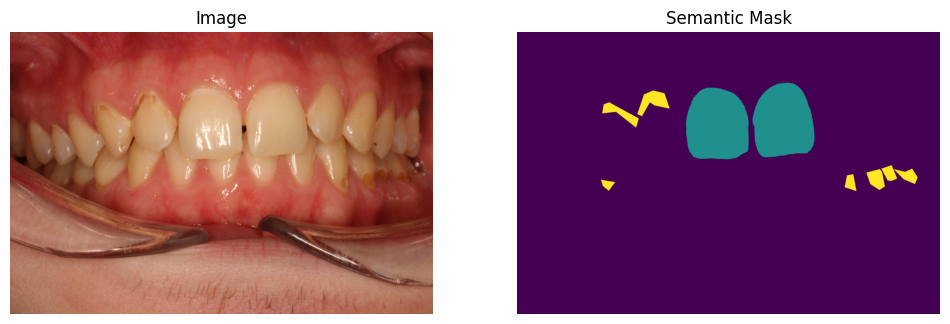

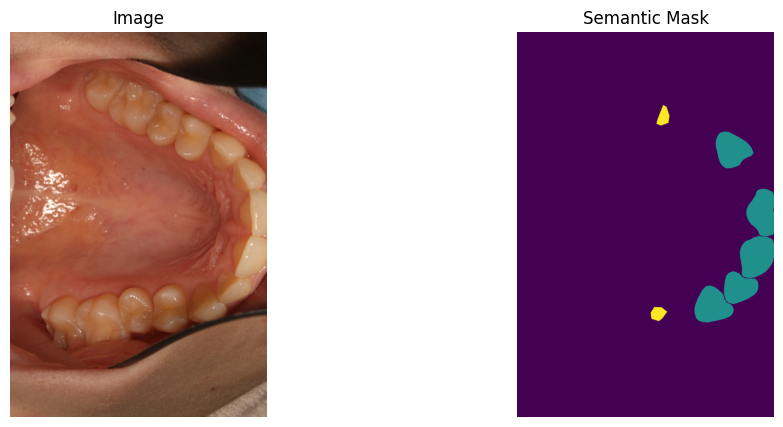

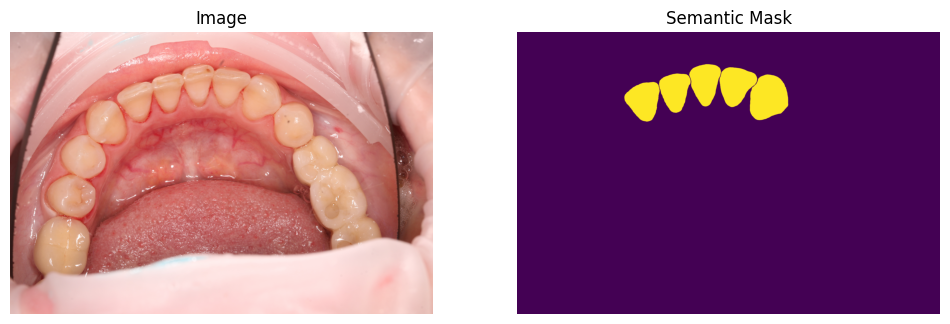

In [28]:
sample_mask_paths = list((DEEPLAB_MASKS / "train").glob("*.png"))

for mask_path in random.sample(sample_mask_paths, min(3, len(sample_mask_paths))):
    img_path = DEEPLAB_IMAGES / "train" / f"{mask_path.stem}.jpg"

    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Image")

    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.axis("off")
    plt.title("Semantic Mask")

    plt.show()

In [29]:
class AlphaDentSemanticDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.image_paths = sorted(list(self.image_dir.glob("*.jpg")))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_dir / f"{img_path.stem}.png"

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].long()

        return image, mask

In [30]:
DEEPLAB_IMGSZ = 512
DEEPLAB_BATCH = 4

train_transform = A.Compose([
    A.Resize(DEEPLAB_IMGSZ, DEEPLAB_IMGSZ),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(DEEPLAB_IMGSZ, DEEPLAB_IMGSZ),
    A.Normalize(),
    ToTensorV2()
])

train_dataset = AlphaDentSemanticDataset(
    DEEPLAB_IMAGES / "train",
    DEEPLAB_MASKS / "train",
    transform=train_transform
)

val_dataset = AlphaDentSemanticDataset(
    DEEPLAB_IMAGES / "val",
    DEEPLAB_MASKS / "val",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=DEEPLAB_BATCH,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=DEEPLAB_BATCH,
    shuffle=False,
    num_workers=2
)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))

Train dataset: 1208
Val dataset: 82


In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3  # background + 2 sınıf
)

deeplab_model = deeplab_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(deeplab_model.parameters(), lr=1e-4)

print("Device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Device: cuda


In [32]:
def compute_mean_iou(preds, masks, num_classes=3):
    preds = torch.argmax(preds, dim=1)

    ious = []

    for cls in range(1, num_classes):  # background hariç
        pred_cls = preds == cls
        mask_cls = masks == cls

        intersection = (pred_cls & mask_cls).sum().float()
        union = (pred_cls | mask_cls).sum().float()

        if union == 0:
            continue

        iou = intersection / union
        ious.append(iou.item())

    if len(ious) == 0:
        return 0.0

    return sum(ious) / len(ious)

In [33]:
DEEPLAB_EPOCHS = 30

deeplab_history = []

for epoch in range(DEEPLAB_EPOCHS):
    deeplab_model.train()

    train_loss = 0.0
    train_iou = 0.0

    for images_batch, masks_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{DEEPLAB_EPOCHS} train"):
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        optimizer.zero_grad()

        outputs = deeplab_model(images_batch)
        loss = criterion(outputs, masks_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_iou += compute_mean_iou(outputs.detach(), masks_batch.detach())

    train_loss /= len(train_loader)
    train_iou /= len(train_loader)

    deeplab_model.eval()

    val_loss = 0.0
    val_iou = 0.0

    with torch.no_grad():
        for images_batch, masks_batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{DEEPLAB_EPOCHS} val"):
            images_batch = images_batch.to(device)
            masks_batch = masks_batch.to(device)

            outputs = deeplab_model(images_batch)
            loss = criterion(outputs, masks_batch)

            val_loss += loss.item()
            val_iou += compute_mean_iou(outputs, masks_batch)

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_mIoU": train_iou,
        "val_loss": val_loss,
        "val_mIoU": val_iou
    }

    deeplab_history.append(row)

    print(row)

df_deeplab_history = pd.DataFrame(deeplab_history)
df_deeplab_history.tail()

Epoch 1/30 train:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 1/30 val:   0%|          | 0/21 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.3767251458191714, 'train_mIoU': 0.15857233363138654, 'val_loss': 0.3020301227058683, 'val_mIoU': 0.18999248281830833}


Epoch 2/30 train:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 2/30 val:   0%|          | 0/21 [00:00<?, ?it/s]

...

Epoch 4/30 train:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 4/30 val:   0%|          | 0/21 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 0.09405433096682393, 'train_mIoU': 0.23939400915031797, 'val_loss': 0.13422024640299024, 'val_mIoU': 0.20404889042090094}


Epoch 5/30 train:   0%|          | 0/302 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [34]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")
RESULTS_DIR = BASE_DIR / "results" / "alphadent_training"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

try:
    df_deeplab_partial = pd.DataFrame(deeplab_history)

    partial_csv = RESULTS_DIR / "deeplabv3plus_partial_history_stopped.csv"
    df_deeplab_partial.to_csv(partial_csv, index=False)

    print("DeepLab partial history kaydedildi:")
    print(partial_csv)
    display(df_deeplab_partial)

except Exception as e:
    print("deeplab_history bulunamadı veya kaydedilemedi:")
    print(e)

DeepLab partial history kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/deeplabv3plus_partial_history_stopped.csv


,epoch,train_loss,train_mIoU,val_loss,val_mIoU
0,1,0.376725,0.158572,0.302030,0.189992
1,2,0.130763,0.195932,0.351923,0.193000
2,3,0.107057,0.219843,0.167270,0.209804
3,4,0.094054,0.239394,0.134220,0.204049


In [35]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

check_files = [
    BASE_DIR / "results" / "alphadent_training" / "alphadent_seg_model_comparison_first_round_30ep.csv",
    BASE_DIR / "final_models" / "alphadent" / "yolov8m_seg_640_30ep_best.pt",
]

for p in check_files:
    print(p)
    print("Var mı?:", p.exists())
    print("-" * 80)

/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_training/alphadent_seg_model_comparison_first_round_30ep.csv
Var mı?: True
--------------------------------------------------------------------------------
/content/drive/MyDrive/DIS_PROJESI_007/final_models/alphadent/yolov8m_seg_640_30ep_best.pt
Var mı?: True
--------------------------------------------------------------------------------


In [ ]:
DEEPLAB_RUN_DIR = RUNS_DIR / "deeplabv3plus_resnet34_512_30ep"
DEEPLAB_RUN_DIR.mkdir(parents=True, exist_ok=True)

deeplab_model_path = DEEPLAB_RUN_DIR / "deeplabv3plus_resnet34_512_30ep.pth"
torch.save(deeplab_model.state_dict(), deeplab_model_path)

df_deeplab_history.to_csv(RESULTS_DIR / "deeplabv3plus_resnet34_512_30ep_history.csv", index=False)

print("DeepLabV3+ model kaydedildi:")
print(deeplab_model_path)

In [ ]:
deeplab_model.eval()

val_sample_indices = random.sample(range(len(val_dataset)), min(5, len(val_dataset)))

with torch.no_grad():
    for idx in val_sample_indices:
        image_tensor, mask_tensor = val_dataset[idx]

        input_tensor = image_tensor.unsqueeze(0).to(device)
        output = deeplab_model(input_tensor)

        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        true_mask = mask_tensor.cpu().numpy()

        # Görüntüyü normalize halden kabaca görselleştirmek için tekrar okuyalım
        img_path = val_dataset.image_paths[idx]
        raw_img = Image.open(img_path).convert("RGB")

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(raw_img)
        plt.axis("off")
        plt.title("Image")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask)
        plt.axis("off")
        plt.title("True Mask")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask)
        plt.axis("off")
        plt.title("Pred Mask")

        plt.show()

In [ ]:
deeplab_summary = {
    "status": "ok",
    "model": "DeepLabV3+ ResNet34",
    "weights": "imagenet_resnet34",
    "run_name": "deeplabv3plus_resnet34_512_30ep",
    "imgsz": 512,
    "epochs": 30,
    "batch": DEEPLAB_BATCH,
    "metric_type": "semantic_segmentation",
    "val_mIoU": float(df_deeplab_history["val_mIoU"].max()),
    "best_epoch": int(df_deeplab_history.loc[df_deeplab_history["val_mIoU"].idxmax(), "epoch"]),
    "model_path": str(deeplab_model_path)
}

df_deeplab_summary = pd.DataFrame([deeplab_summary])
df_deeplab_summary

In [ ]:
deeplab_summary_csv = RESULTS_DIR / "deeplabv3plus_resnet34_512_30ep_summary.csv"

df_deeplab_summary.to_csv(deeplab_summary_csv, index=False)

print("Kaydedildi:")
print(deeplab_summary_csv)